In [11]:
import numpy as np
import scipy as sp
from scipy.linalg import block_diag
from scipy.stats import unitary_group
from qutip import *
np.set_printoptions(legacy='1.13',linewidth=np.inf, threshold=np.inf, precision=3)

import matplotlib.pyplot as plt

In [29]:
#Gibbs energy dist from beta = 1 case, from the RSJJ model calculation value, single mode coup 1 gamma 1.4
Gibbs = np.array([[0.58412,0,0],[0,0.278235,0],[0,0,0.137646]])
degeneracy = np.array([2,4,3])

#Gibbs state with the degeneracy (Ergodic restriction concerned)
def degen_Gibbs_create(Gib, deg, TF):
    dim = Gib.shape[0]
    
    if dim == len(deg):
        sys_gibbs = []
        for i in range(dim):
        ###### debug ######
            #print(Gibbs[i][i])
            #print(degeneracy[i])
            #print("----------")
        ###### debug ######
            temp = (Gib[i][i], deg[i])
            div = temp[0]/temp[1]

            make_matrix_dim = np.identity(temp[1])
            make_matrix_dim *= div
            
            sys_gibbs.append(make_matrix_dim)
            ###### debug ######
            #print(sys_gibbs)
            ###### debug ######
        ret_matrix = block_diag(*sys_gibbs)
        if TF == False:
            return ret_matrix
        if TF == True:
            return sys_gibbs

    else:
        print("Not available input source")
        return None

In [30]:
Cal_Gibbs = degen_Gibbs_create(Gibbs,degeneracy,False)
Cal_Gibbs

array([[ 0.292,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.292,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.07 ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.07 ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.07 ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.07 ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.046,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.046,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.046]])

In [31]:
#Create Qubit system with coherence
asdf = coherent_dm(2,1+0.2j)
Sys_block = asdf.full()


In [32]:
#System construction, False case
Nup_asdf_qobj = Qobj(Sys_block)
Cal_Gibbs_qobj = Qobj(Cal_Gibbs)
rhoRS_qutip = tensor(Nup_asdf_qobj, Cal_Gibbs_qobj)
rhoRS=rhoRS_qutip.full()

print(np.trace(rhoRS))

(1.000001+0j)


In [ ]:
def Unit_block_diag_compose(sys,bath):
    sys_index = (sys.shape[0])
    bath_index = len(bath)

    #print("system_index",sys_index)

    index_comb = []

    for i in range(sys_index):
        for j in range(bath_index):
            comb = ((i,i),j)
            index_comb.append(comb)

    sorted_comb = sorted(index_comb, key=lambda x: x[0][0] + x[1])
    avail_values = [sorted_comb[i][0][0] + sorted_comb[i][1] for i in range(len(sorted_comb))] #possible combinations for indices corresponding energy conditions

    value_bound = (min(avail_values),max(avail_values))
    print("limited values : ", value_bound)

    #avail_values = avail_values[1:-1]
    #sorted_comb = sorted_comb[1:-1]
    print("sorted result : ",sorted_comb)
    print("avail_values : ",avail_values)

    sub_block_arr = []
    for k in range(len(sorted_comb)):
        sub_block = np.zeros(bath[sorted_comb[k][1]].shape[0])
        # This condition only acts under qubit case
        #print(sys[sorted_comb[k][0][0],sorted_comb[k][0][1]])
        sub_block = unitary_group.rvs(bath[sorted_comb[k][1]].shape[0])
        sub_block_arr.append(sub_block)
                
    print(sub_block_arr)
    #print(len(sub_block_arr))

    arrsize = 0 
    for l in range(len(sub_block_arr)):
        arrsize += sub_block_arr[l].shape[0]

    total_block = np.zeros((arrsize,arrsize))
    
    # 기존 오류 있는 루프 구조 대신 순차적 블록 배치
    row_offset = 0
    col_offset = 0

    for sub_block in sub_block_arr:
        size = sub_block.shape[0]
        total_block[row_offset:row_offset+size, col_offset:col_offset+size] = sub_block
        row_offset += size
        col_offset += size


    print(total_block)
    #total_block = np.block([[block00,np.zeros((block00.shape[0],block00.shape[0]))],[np.zeros((block00.shape[0],block00.shape[0])),block11]])

    return total_block

limited values :  (0, 3)
sorted result :  [((0, 0), 0), ((0, 0), 1), ((1, 1), 0), ((0, 0), 2), ((1, 1), 1), ((1, 1), 2)]
avail_values :  [0, 1, 1, 2, 2, 3]
[array([[-0.362+0.783j, -0.112-0.494j],
       [ 0.505-0.03j ,  0.652-0.565j]]), array([[-0.236+0.287j,  0.029-0.143j,  0.354-0.017j,  0.735+0.418j],
       [ 0.428-0.34j , -0.297-0.486j,  0.552+0.26j , -0.053-0.033j],
       [ 0.094-0.537j, -0.138-0.23j , -0.649+0.039j,  0.433+0.143j],
       [ 0.394+0.332j, -0.625+0.438j, -0.146+0.241j,  0.030+0.269j]]), array([[ 0.240-0.868j,  0.096-0.424j],
       [ 0.349+0.259j, -0.747-0.503j]]), array([[ 0.359+0.109j,  0.286-0.298j, -0.376-0.74j ],
       [-0.386+0.51j , -0.102-0.75j ,  0.082+0.109j],
       [-0.410-0.532j, -0.488-0.137j,  0.190-0.506j]]), array([[-0.301+0.025j,  0.495+0.457j,  0.320-0.523j, -0.123+0.251j],
       [-0.103+0.439j,  0.424+0.206j, -0.086+0.395j, -0.271-0.581j],
       [-0.384-0.202j,  0.184+0.06j , -0.319+0.559j, -0.169+0.576j],
       [-0.625+0.356j, -0.446-0.29

/tmp/ipykernel_23561/1536879304.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  total_block[row_offset:row_offset+size, col_offset:col_offset+size] = sub_block


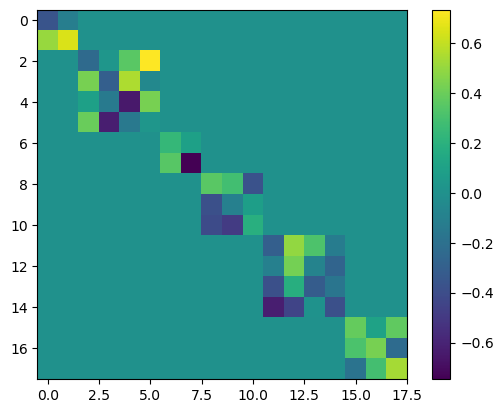

In [34]:
Cal_Gibbs_T = degen_Gibbs_create(Gibbs,degeneracy,True)
testbed = Unit_block_diag_compose(Sys_block,Cal_Gibbs_T)

plt.imshow(testbed.real)
plt.colorbar()

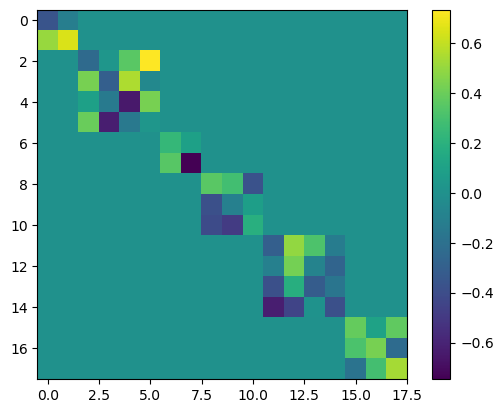

In [41]:
c_testbed = testbed.conj().T
product = np.dot(testbed,c_testbed)

plt.imshow(testbed.real)
plt.colorbar()


--- Identifying Total Energy Subspaces (Example Energies) ---
E_total = 0.0 : Dimension d_0 = 4, Indices = [0 1 2 3]
E_total = 1.0 : Dimension d_1 = 8, Indices = [ 4  5  6  7 12 13 14 15]
E_total = 2.0 : Dimension d_2 = 8, Indices = [ 8  9 10 11 16 17 18 19]
E_total = 3.0 : Dimension d_3 = 4, Indices = [20 21 22 23]

--- Comparing Calculated Dimensions with User Input ---
E_total=0.0: User Dim=2, Calculated Dim=4 -> Match: False
E_total=1.0: User Dim=6, Calculated Dim=8 -> Match: False
E_total=2.0: User Dim=7, Calculated Dim=8 -> Match: False
E_total=3.0: User Dim=3, Calculated Dim=4 -> Match: False

Please check the assumed System/Bath energy levels (Es, Er_vals) match your model.

--- Verifying Final U properties ---
Is Final U unitary? : True


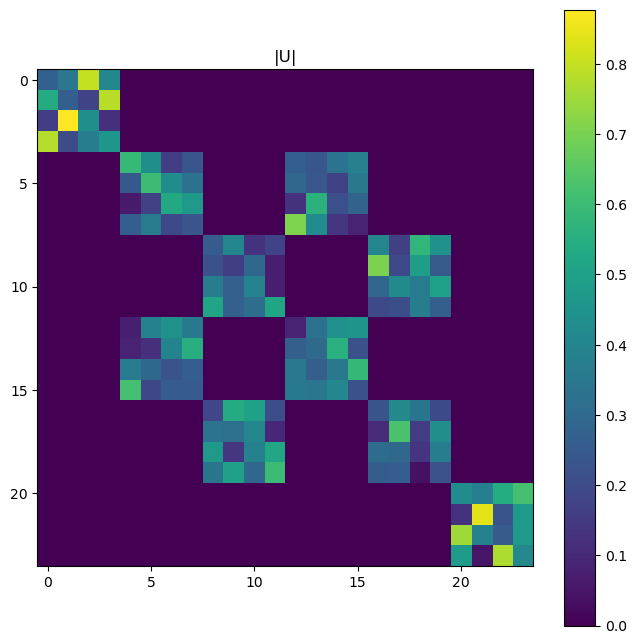

In [44]:
import numpy as np
from scipy.linalg import block_diag
from scipy.stats import unitary_group
# from qutip import Qobj # 필요시 QuTiP 객체 변환

np.set_printoptions(legacy='1.13',linewidth=np.inf, threshold=np.inf, precision=3)

# --- 1. 시스템 및 배스 기본 정보 (사용자 코드 기반) ---
sys_dim = 2
# degeneracy = np.array([4, 4, 4]) # 사용자 코드에서
# bath_dim = degeneracy.sum() # 12
bath_dim = 12 # 총 배스 차원
total_dim = sys_dim * bath_dim # 24

# --- 2. (★중요★) 실제 에너지 값 정의 및 부분 공간 식별 ---
# !!! 아래 Es, Er 값은 예시이며, 사용자의 실제 모델에 맞게 수정해야 합니다 !!!
# 예시 에너지: Es=[0, 1], Er은 degeneracy=[4,4,4]를 가지며 E=0,1,2 에 해당한다고 가정
Es = np.array([0.0, 1.0]) # 예시 시스템 에너지 (값 변경 가능)
Er_vals = np.array([0.0, 1.0, 2.0]) # 예시 배스 에너지 레벨 (값 변경 가능)
degeneracy = np.array([4, 4, 4]) # 각 배스 에너지 레벨의 축퇴도
if degeneracy.sum() != bath_dim:
    raise ValueError("Sum of degeneracies does not match bath_dim")
Er = np.concatenate([np.full(degeneracy[i], Er_vals[i]) for i in range(len(Er_vals))])

# 전체 기저 상태 |s_i>|r_k> 에 대한 총 에너지 계산
total_energies = np.zeros(total_dim)
basis_map_idx_to_tuple = {} # 전체 인덱스 -> (i_sys, k_bath)
basis_map_tuple_to_idx = {} # (i_sys, k_bath) -> 전체 인덱스
idx = 0
for i in range(sys_dim):
    for k in range(bath_dim):
        total_energies[idx] = Es[i] + Er[k]
        basis_map_idx_to_tuple[idx] = (i, k)
        basis_map_tuple_to_idx[(i, k)] = idx
        idx += 1

# 각 총 에너지 값(E_l)에 해당하는 기저 상태 인덱스 및 차원(d_l) 계산
unique_total_Es = np.unique(total_energies)
subspace_indices = {} # E_l -> [index1, index2, ...]
subspace_dims = {}    # E_l -> d_l
original_indices = np.arange(total_dim)

print("--- Identifying Total Energy Subspaces (Example Energies) ---")
for E_l in unique_total_Es:
    # 수치 오류를 고려하여 가까운 값 찾기
    indices_l = original_indices[np.isclose(total_energies, E_l)]
    subspace_indices[E_l] = indices_l
    subspace_dims[E_l] = len(indices_l)
    print(f"E_total = {E_l:.1f} : Dimension d_{E_l:.0f} = {subspace_dims[E_l]}, Indices = {indices_l}")

# --- 사용자께서 제공한 차원 정보와 비교 (선택 사항) ---
user_dims = {0.0: 2, 1.0: 6, 2.0: 7, 3.0: 3} # 사용자가 E=0,1,2,3 에 대해 알려준 차원
all_dims_match = True
print("\n--- Comparing Calculated Dimensions with User Input ---")
for E_l, user_d_l in user_dims.items():
    if E_l in subspace_dims:
        calculated_d_l = subspace_dims[E_l]
        match = (calculated_d_l == user_d_l)
        print(f"E_total={E_l:.1f}: User Dim={user_d_l}, Calculated Dim={calculated_d_l} -> Match: {match}")
        if not match:
            all_dims_match = False
    else:
        print(f"E_total={E_l:.1f}: User specified Dim={user_d_l}, but this energy level not found in calculation.")
        all_dims_match = False

if not all_dims_match:
    print("\nWarning: Calculated subspace dimensions do not match user specification!")
    print("Please check the assumed System/Bath energy levels (Es, Er_vals) match your model.")
    # 여기서는 계산된 차원을 기반으로 계속 진행하거나, 사용자 차원을 강제로 사용할 수 있음
    # 우선 계산된 차원 사용:
    active_energies_with_dim = {E_l: subspace_dims[E_l] for E_l in user_dims.keys() if E_l in subspace_dims}
    # 또는 사용자 차원 강제 사용 (주의: 전체 차원이 맞지 않을 수 있음)
    # active_energies_with_dim = user_dims
else:
    print("Calculated dimensions match user specification.")
    active_energies_with_dim = user_dims


# --- 3. 에너지 보존 유니터리 U 구성 함수 ---
def construct_energy_preserving_unitary(total_dim, subspace_indices, subspace_dims, active_energies_dict):
    """
    총 에너지 보존 유니터리 U를 구성합니다.

    Args:
        total_dim (int): 전체 힐버트 공간 차원 (ds * dr)
        subspace_indices (dict): {E_l: [idx1, idx2,...]} 각 에너지 레벨에 속하는 기저 인덱스
        subspace_dims (dict): {E_l: d_l} 각 에너지 레벨의 부분 공간 차원
        active_energies_dict (dict): {E_l: d_l} 상호작용(무작위 유니터리)을 적용할 에너지 레벨과 차원

    Returns:
        np.ndarray: 구성된 전체 유니터리 행렬 U
    """
    U_total = np.zeros((total_dim, total_dim), dtype=complex)

    processed_indices = set() # 처리된 인덱스 추적

    # 활성 에너지 레벨에 대해 무작위 유니터리 블록 생성 및 배치
    for E_l, dim_l in active_energies_dict.items():
        if E_l not in subspace_indices:
            print(f"Warning: Energy E_l={E_l} not found in calculated subspaces. Skipping.")
            continue
        if dim_l == 0:
            continue
        if subspace_dims[E_l] != dim_l:
             print(f"Warning: Dimension mismatch for E_l={E_l}. Using user provided dim {dim_l} instead of calculated {subspace_dims[E_l]}.")
             # 실제로는 에러 처리 또는 계산된 차원 사용 권장
        
        # 무작위 d_l x d_l 유니터리 생성
        U_l = unitary_group.rvs(dim_l)

        # 해당 부분 공간의 원래 기저 인덱스 가져오기
        original_indices_l = subspace_indices[E_l]
        if len(original_indices_l) != dim_l:
             print(f"Error: Mismatch between provided dimension {dim_l} and indices length {len(original_indices_l)} for E_l={E_l}")
             continue # 에러 발생 시 해당 블록 건너뛰기

        # U_l 블록을 U_total의 올바른 위치에 배치
        rows, cols = np.ix_(original_indices_l, original_indices_l)
        U_total[rows, cols] = U_l
        processed_indices.update(original_indices_l)

    # 처리되지 않은 나머지 인덱스에 대해 단위 행렬 배치
    remaining_indices = np.setdiff1d(np.arange(total_dim), list(processed_indices))
    if len(remaining_indices) > 0:
        # 남은 인덱스들에 대해 단위 행렬 적용
        rows, cols = np.ix_(remaining_indices, remaining_indices)
        U_total[rows, cols] = np.identity(len(remaining_indices))

    return U_total

# --- 4. U 행렬 생성 및 검증 ---
# 위에서 계산/확인된 부분 공간 정보와 사용자 요청 차원을 사용
U_final = construct_energy_preserving_unitary(total_dim, subspace_indices, subspace_dims, active_energies_with_dim)

print("\n--- Verifying Final U properties ---")
# 유니터리 확인
is_unitary = np.allclose(U_final @ U_final.conj().T, np.identity(total_dim))
print(f"Is Final U unitary? : {is_unitary}")

# 에너지 보존 확인
#comm = U_final @ H_SR - H_SR @ U_final
#commutes = np.allclose(comm, np.zeros((total_dim, total_dim)))
#print(f"Does Final U commute with H_SR? : {commutes}")

#if is_unitary and commutes:
#    print("\nSuccessfully constructed the energy-preserving unitary matrix U.")
    # 이제 U_final을 시뮬레이션에 사용할 수 있습니다.
    # 예: rho_prime_SR = U_final @ rho_SR @ U_final.conj().T
    #      sigma_S = partial_trace_numpy(rho_prime_SR, sys_dim, bath_dim)
#else:
#    print("\nError: Final U matrix does not satisfy required properties!")

# (선택) 최종 U 행렬 시각화 (매우 클 수 있음)
# import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(np.abs(U_final), interpolation='nearest', cmap='viridis')
plt.colorbar()
plt.title('|U|')
plt.show()